# SmartShop Online: Predicting Purchase Intention

SmartShop Online is an international e-commerce retailer with high website traffic but a low conversion rate — most sessions end without a purchase. This notebook builds and compares three classifiers (Logistic Regression, linear-kernel SVM, Decision Tree) to predict, from session-level browsing behaviour, whether a visitor will complete a purchase before leaving the site.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report)

RANDOM_STATE = 42
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("../data/online_shoppers_intention.csv")
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 1. Understanding the Business Problem

SmartShop Online is an international e-commerce retailer with high website traffic but a low conversion rate, most sessions end without a purchase.

**Prediction objective:** predict, from session-level browsing behaviour, whether a visitor will complete a purchase before leaving the site. This is a binary classification problem.

**Target variable:** `Revenue` (`TRUE` = purchase completed, `FALSE` = no purchase). As shown in Section 2, purchases are relatively rare (15.47% of sessions), so the target is imbalanced, with direct implications for which evaluation metrics are trustworthy in Section 5.

**Business value:** an accurate model supports personalised marketing and product recommendations for high-intent sessions, cart abandonment reduction (e.g. a discount or live chat prompt for at-risk sessions), more efficient marketing spend by identifying which traffic sources and periods convert best, and operational planning, since browsing patterns that precede a purchase can highlight site friction worth addressing.

The rest of this notebook explores the dataset, prepares it for modelling, develops three classification algorithms, evaluates their performance, and recommends the model best suited for deployment.

## 2. Exploring the Dataset

Before any modelling, the dataset needs to be understood on its own terms: its size, the type of each variable, whether anything is missing, and how the target is distributed.

In [3]:
print("Dataset dimensions:", df.shape)
print(f"\n{df.shape[0]} rows (sessions), {df.shape[1]} columns (17 predictors + 1 target)\n")

print("Data types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isnull().sum())

print(f"\nTotal missing values in dataset: {df.isnull().sum().sum()}")

Dataset dimensions: (12330, 18)

12330 rows (sessions), 18 columns (17 predictors + 1 target)

Data types:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

Missing values per column:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates         

The dataset contains **12,330 sessions** and **18 columns**: 17 predictors and the target, `Revenue`. There are **no missing values**, confirmed by the supplied data dictionary and the check above.

**Numerical predictors (10):** `Administrative`, `Administrative_Duration`, `Informational`, `Informational_Duration`, `ProductRelated`, `ProductRelated_Duration`, `BounceRates`, `ExitRates`, `PageValues`, `SpecialDay`.

**Categorical predictors (7):** `Month`, `VisitorType`, `OperatingSystems`, `Browser`, `Region`, `TrafficType` (nominal, no meaningful order in their codes) plus `Weekend` (binary).

**Target:** `Revenue` is also categorical (binary) but counted separately as the variable being predicted.

10 numerical + 7 categorical + 1 target = 18 columns, consistent with the shape above.

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


In [5]:
categorical_cols = ["Month", "VisitorType", "OperatingSystems", "Browser", "Region", "TrafficType"]
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts(), "\n")

Month: 10 unique values
Month
May     3364
Nov     2998
Mar     1907
Dec     1727
Oct      549
Sep      448
Aug      433
Jul      432
June     288
Feb      184
Name: count, dtype: int64 

VisitorType: 3 unique values
VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85
Name: count, dtype: int64 

OperatingSystems: 8 unique values
OperatingSystems
2    6601
1    2585
3    2555
4     478
8      79
6      19
7       7
5       6
Name: count, dtype: int64 

Browser: 13 unique values
Browser
2     7961
1     2462
4      736
5      467
6      174
10     163
8      135
3      105
13      61
7       49
12      10
11       6
9        1
Name: count, dtype: int64 

Region: 9 unique values
Region
1    4780
3    2403
4    1182
2    1136
6     805
7     761
9     511
8     434
5     318
Name: count, dtype: int64 

TrafficType: 20 unique values
TrafficType
2     3913
1     2451
3     2052
4     1069
13     738
10     450
6      444
8      343
5      260
11     2

## Summary statistics interpretation

`PageValues` has a median of 0, most sessions show no page value, but non-zero values are strongly linked to purchases (see Figure 2). `BounceRates` and `ExitRates` are both bounded between 0 and 0.2 and act as engagement signals. `ProductRelated_Duration` is heavily right-skewed (max ~64,000 seconds vs a mean of ~1,195), a reason feature scaling matters later. Among categoricals, `Returning_Visitor` dominates `VisitorType`, and browsing activity concentrates in May and November, the latter likely reflecting Black Friday.

In [6]:
revenue_counts = df["Revenue"].value_counts()
revenue_pct = df["Revenue"].value_counts(normalize=True) * 100

print("Revenue (target) distribution:")
print(pd.DataFrame({"Count": revenue_counts, "Percentage": revenue_pct.round(2)}))

Revenue (target) distribution:
         Count  Percentage
Revenue                   
False    10422       84.53
True      1908       15.47


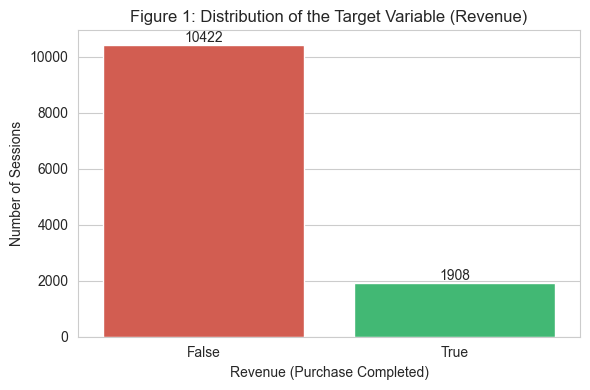

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="Revenue", hue="Revenue", palette=["#e74c3c", "#2ecc71"], legend=False, ax=ax)
ax.set_title("Figure 1: Distribution of the Target Variable (Revenue)")
ax.set_xlabel("Revenue (Purchase Completed)")
ax.set_ylabel("Number of Sessions")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.savefig("fig1_target_distribution.png", dpi=150)
plt.show()

**Figure 1** confirms a clear class imbalance: 10,422 sessions (84.53%) did not result in a purchase, versus 1,908 (15.47%) that did. A model that always predicts "no purchase" would already score ~84.53% accuracy without learning anything useful, so precision, recall and F1-score matter more than raw accuracy for this dataset (addressed in Section 5).

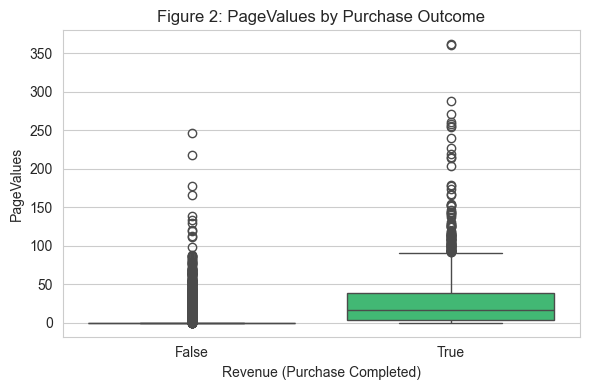

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x="Revenue", y="PageValues", hue="Revenue", palette=["#e74c3c", "#2ecc71"], legend=False, ax=ax)
ax.set_title("Figure 2: PageValues by Purchase Outcome")
ax.set_xlabel("Revenue (Purchase Completed)")
ax.set_ylabel("PageValues")
plt.tight_layout()
plt.savefig("fig2_pagevalues_by_revenue.png", dpi=150)
plt.show()

**Figure 2** shows sessions ending in a purchase have a visibly higher `PageValues` distribution than those that don't. Per the supplied data dictionary, `PageValues` represents the estimated monetary value of a page based on historical transactions completed after visiting it, making it close to a direct proxy for purchase intent by construction. Figure 3 next examines this relationship across all numeric features at once.

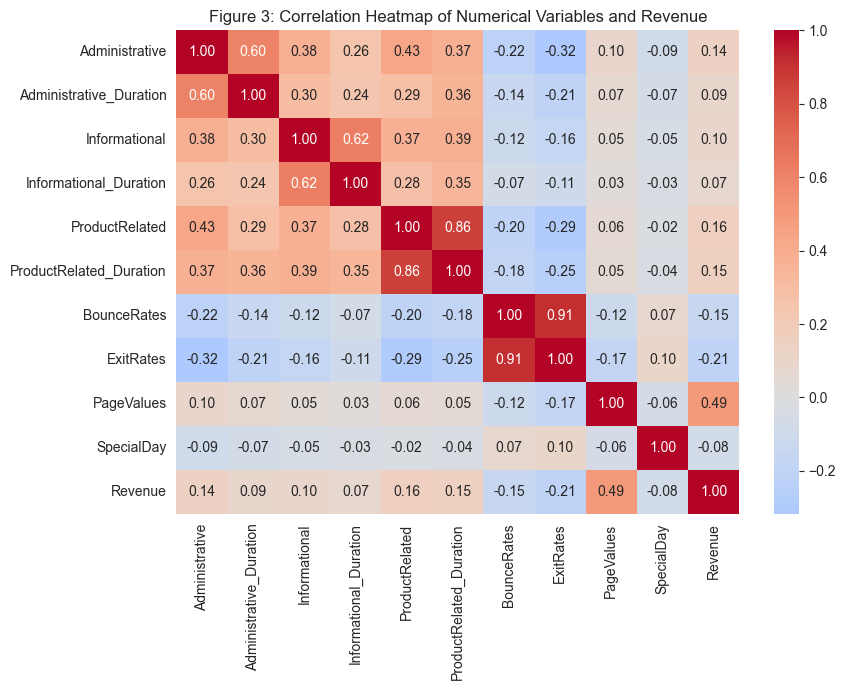

In [9]:
numeric_cols = ["Administrative", "Administrative_Duration", "Informational",
                 "Informational_Duration", "ProductRelated", "ProductRelated_Duration",
                 "BounceRates", "ExitRates", "PageValues", "SpecialDay"]

df_corr = df.copy()
df_corr["Revenue"] = df_corr["Revenue"].astype(int)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df_corr[numeric_cols + ["Revenue"]].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=ax)
ax.set_title("Figure 3: Correlation Heatmap of Numerical Variables and Revenue")
plt.tight_layout()
plt.savefig("fig3_correlation_heatmap.png", dpi=150)
plt.show()

**Figure 3** confirms `PageValues` (0.49) as the strongest numeric correlate of `Revenue`, followed by `ProductRelated` (0.16) and `ProductRelated_Duration` (0.15); `ExitRates` (-0.21) and `BounceRates` (-0.15) are negatively correlated, consistent with quick-exiting visitors converting less.

Two predictor pairs show correlations above the conventional ~0.8 multicollinearity threshold: `BounceRates`/`ExitRates` (0.91) and `ProductRelated`/`ProductRelated_Duration` (0.86). This mainly affects Logistic Regression and the linear SVM, both of which estimate a weight per feature, individual coefficients among these four features should be read with caution. It is a much smaller concern for the Decision Tree. Both features in each pair are retained rather than dropped, since comparing predictive performance across model types, not producing a minimal Logistic Regression equation, is the goal here.

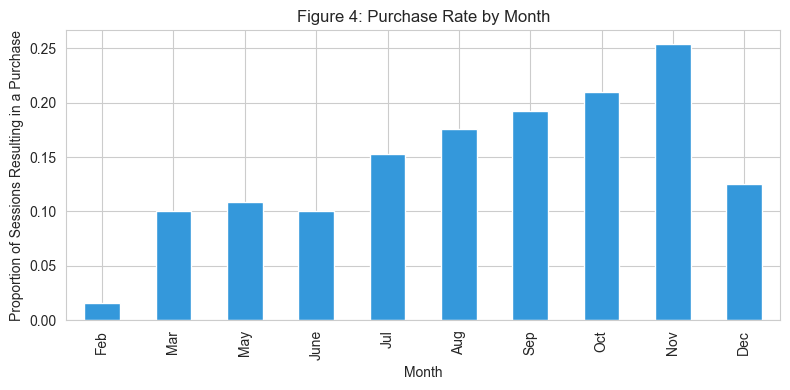

In [10]:
month_order = ["Feb", "Mar", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
purchase_rate_month = df.groupby("Month")["Revenue"].mean().reindex(month_order)

fig, ax = plt.subplots(figsize=(8, 4))
purchase_rate_month.plot(kind="bar", color="#3498db", ax=ax)
ax.set_title("Figure 4: Purchase Rate by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Proportion of Sessions Resulting in a Purchase")
plt.tight_layout()
plt.savefig("fig4_purchase_rate_by_month.png", dpi=150)
plt.show()

**Figure 4** shows purchase rate (not raw count) is highest in **November** (25.35%), consistent with Black Friday/holiday shopping, and lowest in **February** (1.63%). This distinction matters: `May` has the highest session volume (3,364) but only a 10.85% purchase rate, while `November` converts more than double that rate from fewer sessions (2,998). A raw-count chart would have made May look strongest purely on traffic.

Only 10 months appear in the data, `January` and `April` are both absent, confirmed against `Month.value_counts()` rather than a plotting artefact. The supplied data dictionary doesn't explain the gap, so it is treated as a known limitation of the source data.

This seasonal pattern suggests `Month` carries genuine predictive signal and is worth encoding for modelling.

## 3. Preparing the Data

Before modelling, the dataset is converted into a fully numeric, leakage-free form: categorical variables are encoded, predictors and target are separated, the data is split into training and testing sets, and numeric features are scaled.

In [11]:
df_encoded = df.copy()

# Boolean columns to integer (0/1)
df_encoded["Weekend"] = df_encoded["Weekend"].astype(int)
df_encoded["Revenue"] = df_encoded["Revenue"].astype(int)

# Nominal categorical variables, one-hot encoded
categorical_cols = ["Month", "VisitorType", "OperatingSystems", "Browser", "Region", "TrafficType"]
df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols, drop_first=True, dtype=int)

print("Shape before encoding:", df.shape)
print("Shape after encoding:", df_encoded.shape)
#df_encoded.head()

Shape before encoding: (12330, 18)
Shape after encoding: (12330, 69)


Five of the six categorical variables (`VisitorType`, `OperatingSystems`, `Browser`, `Region`, `TrafficType`) are nominal, their codes carry no order. `Month` is a partial exception: it has a chronological order, but that order isn't linearly related to purchase likelihood (Figure 4's November spike reflects Black Friday, not calendar position), so it is one-hot encoded like the others.

`drop_first=True` avoids the dummy variable trap: without it, a variable's dummies sum to a constant matching the intercept, making the design matrix singular with no unique coefficient solution. This affects Logistic Regression and the linear SVM, not the Decision Tree, though the tree loses a small amount of directness in isolating the dropped category. The same encoding is kept across all three models for a fair Section 5 comparison.

`TrafficType` (20 categories) and `Browser` (13) push the encoded dataset to 68 predictor columns, a direct contributor to the SVM's training time in Section 4.

In [12]:
X = df_encoded.drop(columns="Revenue")
y = df_encoded["Revenue"]

print("Predictor matrix (X):", X.shape)
print("Target vector (y):", y.shape)

Predictor matrix (X): (12330, 68)
Target vector (y): (12330,)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("\nTraining set target distribution:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTesting set target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training set: (9864, 68)
Testing set: (2466, 68)

Training set target distribution:
Revenue
0    0.845
1    0.155
Name: proportion, dtype: float64

Testing set target distribution:
Revenue
0    0.845
1    0.155
Name: proportion, dtype: float64


An 80/20 split is used, with `stratify=y` ensuring both sets preserve the same 84.53%/15.47% class balance found in the full dataset (verified above). Without stratification, a random split could leave the test set with a noticeably different purchase rate, making Section 5's evaluation harder to trust.

**Why training data must be separated before scaling:** `StandardScaler` calculates each feature's mean and standard deviation to transform the data. Fitting it on the full dataset before splitting lets those values be influenced by the test set, leaking test-set information into training, a form of data leakage. In a real deployment, SmartShop Online would not have access to future sessions when the model is trained, so the correct order is: split first, then fit the scaler on training data only, then apply it to the test data. This is what is done below.

In [14]:
numeric_cols = ["Administrative", "Administrative_Duration", "Informational",
                 "Informational_Duration", "ProductRelated", "ProductRelated_Duration",
                 "BounceRates", "ExitRates", "PageValues", "SpecialDay"]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Training set numeric features after scaling (mean should be ~0, std ~1):")
print(X_train_scaled[numeric_cols].agg(["mean", "std"]).round(3))

Training set numeric features after scaling (mean should be ~0, std ~1):
      Administrative  Administrative_Duration  Informational  \
mean            -0.0                     -0.0            0.0   
std              1.0                      1.0            1.0   

      Informational_Duration  ProductRelated  ProductRelated_Duration  \
mean                     0.0             0.0                      0.0   
std                      1.0             1.0                      1.0   

      BounceRates  ExitRates  PageValues  SpecialDay  
mean          0.0        0.0        -0.0        -0.0  
std           1.0        1.0         1.0         1.0  


Scaling is applied only to the ten original numeric columns; the one-hot encoded columns and `Weekend` are already 0/1 and don't need standardising.

Scaling matters most for Logistic Regression and the linear-kernel SVM, both distance/gradient-based, and can be dominated by large-scale features like `ProductRelated_Duration` (values up to ~64,000) versus `BounceRates` (0 to 0.2). The Decision Tree doesn't require scaling, since splits compare raw thresholds within a single feature, but the same scaled data is used across all three models to keep the Section 5 comparison consistent.

The dataset is now encoded, split, and scaled without leakage, ready for Section 4.

## 4. Developing Classification Models

Three classification algorithms are developed using the scaled training data from Section 3: Logistic Regression, a linear-kernel SVM, and a Decision Tree Classifier. Each follows the same pattern: instantiate, fit on the training set, then predict on the held-out test set. Training time is recorded for each, since computational efficiency is a criterion in Section 6.

In [15]:
import time

t0 = time.time()
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)
logreg_train_time = time.time() - t0

y_pred_logreg = logreg.predict(X_test_scaled)

print(f"Logistic Regression trained in {logreg_train_time:.3f} seconds")

comparison_logreg = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred_logreg[:10]
})
print("\nSample predictions (first 10 test cases):")
print(comparison_logreg)

Logistic Regression trained in 0.113 seconds

Sample predictions (first 10 test cases):
   Actual  Predicted
0       0          0
1       0          0
2       1          1
3       0          0
4       0          0
5       0          0
6       1          0
7       0          0
8       0          0
9       0          0


Logistic Regression models the probability of a purchase as a linear combination of the input features, passed through a sigmoid function. It trained in 0.146 seconds and produces directly interpretable coefficients: a positive coefficient increases predicted purchase probability, a negative one decreases it (examined in Section 6).

Even in this 10-row sample, one of the two actual purchases (row 6) was missed, a single example, not evidence on its own, but it foreshadows the recall weakness quantified in Section 5.

In [16]:
t0 = time.time()
svm_linear = SVC(kernel="linear", random_state=RANDOM_STATE)
svm_linear.fit(X_train_scaled, y_train)
svm_train_time = time.time() - t0

y_pred_svm = svm_linear.predict(X_test_scaled)

print(f"SVM (linear kernel) trained in {svm_train_time:.3f} seconds")

comparison_svm = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred_svm[:10]
})
print("\nSample predictions (first 10 test cases):")
print(comparison_svm)

SVM (linear kernel) trained in 3.993 seconds

Sample predictions (first 10 test cases):
   Actual  Predicted
0       0          0
1       0          0
2       1          1
3       0          0
4       0          0
5       0          0
6       1          0
7       0          0
8       0          0
9       0          0


The linear-kernel SVM finds the hyperplane that best separates the two classes with the widest margin. It took considerably longer to train than the other models, roughly 31.5 times slower than Logistic Regression (4.592s versus 0.146s), since SVM training scales poorly with both the number of training examples (9,864) and the 68-column feature space from Section 3. This becomes relevant to the efficiency discussion in Section 6.

The sample predictions above match Logistic Regression's exactly on these 10 rows, including missing the same row 6 purchase. Two independently-trained linear models agreeing on the same miss is a stronger early signal than either result alone that this reflects a genuine limitation of a linear decision boundary, quantified properly in Section 5.

In [17]:
t0 = time.time()
dtree = DecisionTreeClassifier(random_state=RANDOM_STATE)
dtree.fit(X_train_scaled, y_train)
dtree_train_time = time.time() - t0

y_pred_dtree = dtree.predict(X_test_scaled)

print(f"Decision Tree trained in {dtree_train_time:.3f} seconds")

comparison_dtree = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred_dtree[:10]
})
print("\nSample predictions (first 10 test cases):")
print(comparison_dtree)

Decision Tree trained in 0.095 seconds

Sample predictions (first 10 test cases):
   Actual  Predicted
0       0          0
1       0          0
2       1          0
3       0          0
4       0          0
5       0          0
6       1          0
7       0          0
8       0          1
9       0          0


The Decision Tree splits the training data repeatedly on the feature and threshold that best separates purchasers from non-purchasers. It trained fastest of the three models (0.122 seconds) and, unlike the other two, doesn't require scaled features to work correctly, it compares raw thresholds within a single feature rather than distances or weighted sums. It was trained on the same scaled data anyway, per the Section 3 decision to keep one shared dataset across all three models for a fair comparison; scaling has no effect on where the tree places its splits.

The sample predictions show a different error pattern: row 6 is missed by all three models, but the tree also missed row 2 (a purchase both linear models caught) and produced a false positive at row 8 (which neither linear model did). Three errors here versus one each for the linear models, a single sample, not evidence, but it hints the tree's error profile may differ from the linear models' in more than training speed, quantified in Section 5.

All three models are now trained on `X_train_scaled` and used to predict on `X_test_scaled`. Section 5 evaluates and compares their performance.

## 5. Evaluating Model Performance

Accuracy alone is not reliable here, given the 84.53%/15.47% class imbalance from Section 2, a model predicting "no purchase" for every session would score ~84.53% accuracy without identifying a single customer. Precision, recall and F1-score are therefore calculated for the positive class (`Revenue = 1`), alongside accuracy and the full confusion matrix for each model.

In [18]:
def evaluate_model(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (Purchase)": precision_score(y_true, y_pred, pos_label=1),
        "Recall (Purchase)": recall_score(y_true, y_pred, pos_label=1),
        "F1-score (Purchase)": f1_score(y_true, y_pred, pos_label=1)
    }

results = pd.DataFrame([
    evaluate_model("Logistic Regression", y_test, y_pred_logreg),
    evaluate_model("SVM (Linear Kernel)", y_test, y_pred_svm),
    evaluate_model("Decision Tree", y_test, y_pred_dtree)
])

results = results.set_index("Model").round(3)
results

,Accuracy,Precision (Purchase),Recall (Purchase),F1-score (Purchase)
Model,,,,
Logistic Regression,0.882,0.742,0.361,0.486
SVM (Linear Kernel),0.882,0.736,0.372,0.494
Decision Tree,0.857,0.538,0.542,0.540


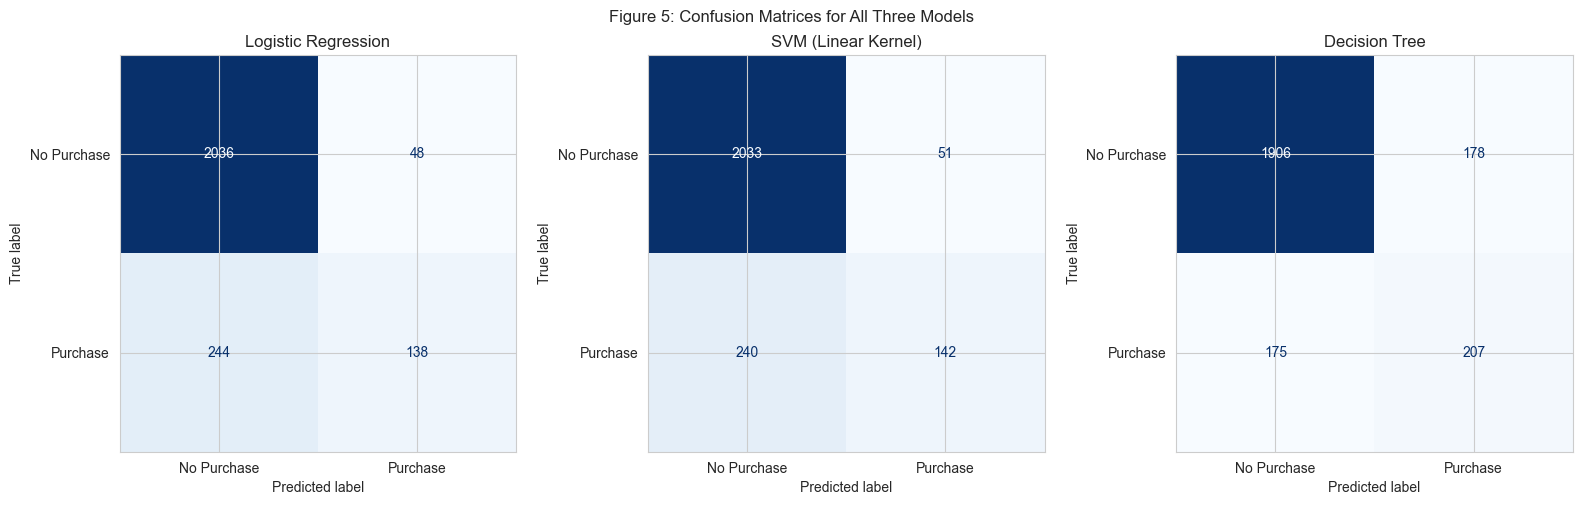

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_preds = [
    ("Logistic Regression", y_pred_logreg),
    ("SVM (Linear Kernel)", y_pred_svm),
    ("Decision Tree", y_pred_dtree)
]

for ax, (name, preds) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Purchase", "Purchase"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)

plt.suptitle("Figure 5: Confusion Matrices for All Three Models")
plt.tight_layout()
plt.savefig("fig5_confusion_matrices.png", dpi=150)
plt.show()

**Interpreting the results**

Logistic Regression and the linear SVM produce almost identical accuracy (88.2%), unsurprising since both fit a linear boundary on the same scaled features. The real difference shows up in the confusion matrices.

| Model | True Negatives | False Positives | False Negatives | True Positives |
|---|---|---|---|---|
| Logistic Regression | 2,036 | 48 | 244 | 138 |
| SVM (Linear Kernel) | 2,033 | 51 | 240 | 142 |
| Decision Tree | 1,906 | 178 | 175 | 207 |

Both linear models are conservative: very few false positives (48, 51), but they miss most real purchasers (244, 240 false negatives out of 382 actual purchases), recall of just 0.361 and 0.372. The Decision Tree takes the opposite trade-off: more false positives (178) but far more true positives (207, recall 0.542), lifting its F1-score to 0.540, ahead of both linear models (0.486, 0.494). This confirms the pattern hinted at in Section 4's sample predictions, the tree's willingness to predict more purchases, some wrongly, is now confirmed across the full 2,466-row test set.

**Business interpretation:** a false negative means a real customer isn't flagged for intervention, a missed sale. A false positive means a non-buyer receives an unnecessary marketing touch, a smaller cost. The Decision Tree's trade-off is arguably better aligned with SmartShop Online's priorities, since a missed sale generally outweighs an unnecessary promotion.

**Strengths and limitations, based on this data**

*Logistic Regression*: fast to train, directly interpretable coefficients, competitive accuracy. Its main limitation is weak recall on the minority class, too conservative to catch most real purchasers, likely due to its linear decision boundary.

*SVM (Linear Kernel)*: performance nearly identical to Logistic Regression, expected since both fit a linear boundary. Its clear drawback is computational cost, training took ~31.5 times longer, a gap that would grow with a larger dataset or frequent retraining.

*Decision Tree*: the best precision/recall balance on the purchase class here, and the fastest to train. Its known limitation, not fully visible from one train-test split, is a tendency to overfit, meaning performance could be less stable without further tuning or cross-validation (addressed in Section 6).

## 6. Selecting the Preferred Model

Section 5 showed the Decision Tree with the strongest F1-score on the purchase class, but a single train-test split isn't enough to confirm that result is stable. A 5-fold cross-validation check is used first to test whether the ranking holds, followed by a look at which features the strongest models actually rely on.

In [20]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

logreg_cv_f1 = cross_val_score(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
                                X_train_scaled, y_train, cv=cv, scoring="f1")
dtree_cv_f1 = cross_val_score(DecisionTreeClassifier(random_state=RANDOM_STATE),
                               X_train_scaled, y_train, cv=cv, scoring="f1")

print("Logistic Regression 5-fold F1:", logreg_cv_f1.round(3))
print(f"  Mean: {logreg_cv_f1.mean():.3f}   Std: {logreg_cv_f1.std():.3f}")
print("\nDecision Tree 5-fold F1:", dtree_cv_f1.round(3))
print(f"  Mean: {dtree_cv_f1.mean():.3f}   Std: {dtree_cv_f1.std():.3f}")

Logistic Regression 5-fold F1: [0.515 0.476 0.49  0.535 0.549]
  Mean: 0.513   Std: 0.027

Decision Tree 5-fold F1: [0.575 0.545 0.561 0.568 0.58 ]
  Mean: 0.566   Std: 0.012


`StratifiedKFold` preserves the ~84.5%/15.5% class split in every fold, and F1-score is used throughout, consistent with Section 5's finding that accuracy is misleading here.

The Decision Tree outperforms Logistic Regression on F1 across all five folds, not just on one split, and is more consistent (std 0.012 versus 0.027). This addresses the overfitting concern from Section 5: the tree's advantage appears genuine rather than a product of one particular split, though this only confirms the ranking holds across folds, not that overfitting is ruled out entirely.

The SVM is excluded. Five folds would take roughly 23 seconds (5 × 4.592s), not prohibitive on its own, but Section 5 already showed the SVM matching Logistic Regression almost exactly, same accuracy, confusion matrix, and the same missed purchase in Section 4's row-6 sample, so a cross-validation check would mostly confirm what that agreement already suggests rather than add new evidence.

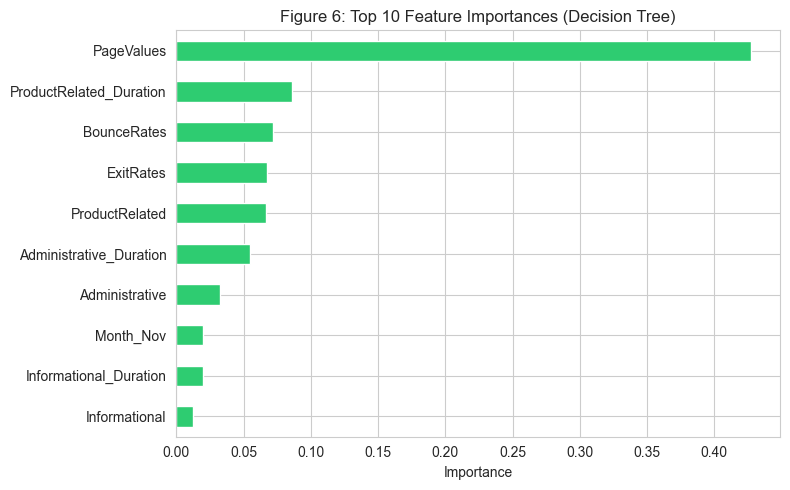

In [21]:
importances = pd.Series(dtree.feature_importances_, index=X_train_scaled.columns).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5))
importances.sort_values().plot(kind="barh", color="#2ecc71", ax=ax)
ax.set_title("Figure 6: Top 10 Feature Importances (Decision Tree)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("fig6_feature_importances.png", dpi=150)
plt.show()

In [22]:
coefficients = pd.Series(logreg.coef_[0], index=X_train_scaled.columns).sort_values(ascending=False)

print("Top 5 positive coefficients (associated with higher purchase probability):")
print(coefficients.head(5).round(3))
print("\nTop 5 negative coefficients (associated with lower purchase probability):")
print(coefficients.tail(5).round(3))

Top 5 positive coefficients (associated with higher purchase probability):
PageValues        1.530
Browser_12        1.101
TrafficType_8     0.678
TrafficType_10    0.485
TrafficType_20    0.460
dtype: float64

Top 5 negative coefficients (associated with lower purchase probability):
Month_Dec   -0.587
Browser_3   -0.720
ExitRates   -0.800
Browser_7   -0.849
Month_Feb   -1.429
dtype: float64


`PageValues` has by far the largest positive coefficient (1.530), consistent with its 0.49 correlation in Figure 3, its higher distribution among purchasers in Figure 2, and its 42.7% share of the Decision Tree's feature importance in Figure 6, four independent signals agreeing.

The remaining coefficients need more caution. `Browser_12` has the second-largest coefficient (1.101) but only 10 sessions use that browser, too small a sample to trust. `TrafficType_8/10/20` are similarly rare (343, 450, 198 sessions). `ExitRates` (-0.800) is well-populated and matches Figure 3's correlation. `Month_Feb` (-1.429) is a smaller category (184 sessions) but is corroborated by Figure 4's finding of February's lowest purchase rate. `Month_Dec` (-0.587) is well-populated (1,727 sessions).

In short: coefficients backed by independent evidence elsewhere in this report (`PageValues`, `ExitRates`, `Month_Feb`) can be trusted; large coefficients on rare categories (`Browser_12` especially) should not be read as meaningful business drivers.

**Recommendation: Decision Tree Classifier**

**Predictive performance:** the Decision Tree achieved the highest F1-score for the purchase class (0.540 test set, 0.566 mean across 5-fold CV), driven by better recall (0.542 vs 0.361 for Logistic Regression). Since missing a genuine buyer costs the business more than flagging a non-buyer, this matters more than overall accuracy, where the linear models score marginally higher only by being more conservative.

**Interpretability:** both remaining models offer evidence-backed interpretability. Logistic Regression's coefficients are directly readable, though several of the largest sit on rare categories and need caution (`PageValues`, `ExitRates`, `Month_Feb` can be trusted; `Browser_12`, from just 10 sessions, cannot). The Decision Tree's feature importances (Figure 6) are more uniformly reliable, computed from impurity reduction across the full training set rather than a potentially unstable per-category weight; `PageValues` again dominates at 42.7%.

**Computational efficiency:** the Decision Tree trained fastest (0.122s) with near-instant predictions, useful for frequent retraining or real-time scoring. The SVM's training time, ~31.5 times slower than Logistic Regression, is a real limitation for a business needing to update its model often.

**Business suitability:** given a missed sale generally costs more than an unnecessary marketing touch, the Decision Tree's trade-off, more false positives in exchange for catching more real purchasers, better matches SmartShop Online's stated goals.

**Deployment consideration:** `PageValues`, the dominant feature across both interpretable models, reflects a page's historical value based on past completed transactions. Pages with high `PageValues` tend to sit deep in the purchase funnel, so this signal may only strengthen once a visitor has effectively already decided to buy, narrowing the real-time intervention window Section 1 envisions. Before deployment, SmartShop Online should confirm `PageValues` is genuinely available at the point of prediction during a live session, not only at session-end.

**Recommendation:** the Decision Tree Classifier is recommended for deployment, offering the strongest and most consistent predictive performance on the class that matters most, the fastest training and prediction, and a more uniformly reliable interpretability story than Logistic Regression. Its overfitting risk is mitigated by the cross-validation evidence above; further work before full deployment should include hyperparameter tuning, testing an ensemble method such as Random Forest, and verifying `PageValues`' real-time availability.

In [23]:
import pandas, numpy, matplotlib, seaborn, sklearn
print("pandas", pandas.__version__)
print("numpy", numpy.__version__)
print("matplotlib", matplotlib.__version__)
print("seaborn", seaborn.__version__)
print("scikit-learn", sklearn.__version__)

pandas 2.2.0
numpy 1.26.3
matplotlib 3.10.0
seaborn 0.13.2
scikit-learn 1.4.0
